# **Hotel Review Sentiment Classification**

NLP Group Project - Basic Lab: Introduction to AI

Group members: Leonardo Volpe, Zhan Shakarim, Nebi Göncü

Goal: build a binary sentiment classifier (positive / negative) for hotel reviews, starting from Bag-of-Words + Logistic Regression, and then show why that baseline is blind to word order - and fix it with a small Recurrent Neural Network (RNN) that reads the review one word at a time and keeps a memory hidden state.

**Pipeline:**
Raw text -> Preprocessing -> Tokenization -> Encoding -> Padding -> Model -> Prediction


# Setup
**Section owner: Leonardo**

To import important libraries pandas, numpy, scikit-learn,re, collections, json,os, copy and matplotlib.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re
from collections import Counter
import json

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

print("libraries loaded")

libraries loaded


**Dataset:** TripAdvisor Hotel Reviews
Each row has a  review and 1 to 5 star rating.
We used this dataset because its real, user generated, full of negations so we can see that bag of words struggle.


In [13]:
DATA_PATH = "tripadvisor_hotel_reviews.csv"

raw_df = pd.read_csv(DATA_PATH)

print(f"lenght of dataframe: {len(raw_df)} reviews from: '{DATA_PATH}'.")
raw_df.head()

lenght of dataframe: 20491 reviews from: 'tripadvisor_hotel_reviews.csv'.


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


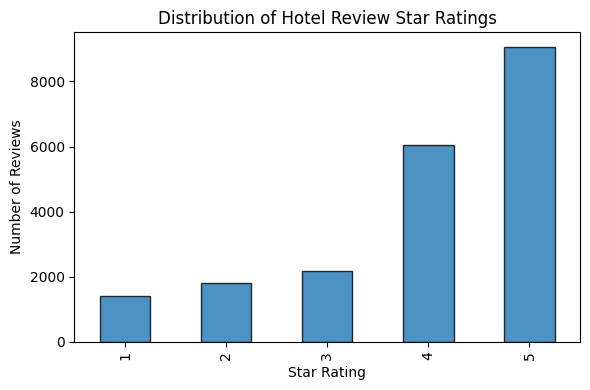

In [14]:
plt.figure(figsize=(6, 4))
raw_df['Rating'].value_counts().sort_index().plot(kind='bar', edgecolor='black', alpha=0.8)
plt.xlabel('Star Rating')
plt.ylabel('Number of Reviews')
plt.title('Distribution of Hotel Review Star Ratings')
plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150)
plt.show()


In [15]:
print("Sample review:")
print("Example, High Rating 5:")
print(raw_df[raw_df["Rating"] == 5])

print("Sample review:")
print("Example, Low Rating 1:")
print(raw_df[raw_df["Rating"] == 1])

Sample review:
Example, High Rating 5:
                                                  Review  Rating
3      unique, great stay, wonderful time hotel monac...       5
4      great stay great stay, went seahawk game aweso...       5
5      love monaco staff husband stayed hotel crazy w...       5
6      cozy stay rainy city, husband spent 7 nights m...       5
8      hotel stayed hotel monaco cruise, rooms genero...       5
...                                                  ...     ...
20473  best best reason affordable better hotels city...       5
20476  night not trust not disappointed stay hotel, s...       5
20480  great play stay stay loyal inn package deal ha...       5
20482  great choice wife chose best western quite bit...       5
20486  best kept secret 3rd time staying charm, not 5...       5

[9054 rows x 2 columns]
Sample review:
Example, Low Rating 1:
                                                  Review  Rating
15     horrible customer service hotel stay february 

# **From 5 Start to Binary Sentiment Label**

We wanted to turn the 5 star review into "Positive" or "Negative" binary type classification.
* Rating 4-5 -> Positive (1)
* Rating 1-2 -> Negative (0)
* Rating 3 -> dropped (neutral)


In [16]:
def rating_to_sentiment(rating):
    if rating >= 4:
        return 1  # positive
    elif rating <= 2:
        return 0  # negative
    return None  # neutral
sentiment_list = []

for rating in raw_df['Rating']:
    result = rating_to_sentiment(rating)
    sentiment_list.append(result)

raw_df['sentiment'] = sentiment_list

raw_df=raw_df.dropna()
raw_df = raw_df.drop(columns=['Rating'])
print(raw_df.head())


                                              Review  sentiment
0  nice hotel expensive parking got good deal sta...        1.0
1  ok nothing special charge diamond member hilto...        0.0
3  unique, great stay, wonderful time hotel monac...        1.0
4  great stay great stay, went seahawk game aweso...        1.0
5  love monaco staff husband stayed hotel crazy w...        1.0


Now lets check the balance.


In [17]:
print(raw_df["sentiment"].value_counts())

sentiment
1.0    15093
0.0     3214
Name: count, dtype: int64


We got : Class balance:
  Negative (0): 3214 (17.6%)
  Positive (1): 15093 (82.4%)
Which is an imbalance but we will fix by tell the model's loss function to pay extra attention to the minority class. We will give the Negative class more "weight" or importance.

But first we will split our data into train, validation and test data.

In [18]:
train_df, temp_df = train_test_split(raw_df, test_size=0.30, random_state=42, stratify=raw_df['sentiment'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['sentiment'])

print(f"Training samples:   {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples:       {len(test_df)}")

Training samples:   12814
Validation samples: 2746
Test samples:       2747


## 2. Text Preprocessing

**Section owner: Zhan**

Raw reviews containts a lot of different not meaningfull text for classification. We apply a cleaning before doing anything else.



*   Lowercase everything
*   Remove nonletters, numbers and punctations
*   Collapse repeated spaces




In [19]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


examples = [
    "The Room was SPOTLESS!!! Staff couldn't have been nicer :)",
    "Never   going    back...   awful, dirty bathroom.",
]
for ex in examples:
    print(f"Original:  {ex}")
    print(f"Processed: {preprocess_text(ex)}\n")


Original:  The Room was SPOTLESS!!! Staff couldn't have been nicer :)
Processed: the room was spotless staff couldnt have been nicer

Original:  Never   going    back...   awful, dirty bathroom.
Processed: never going back awful dirty bathroom



In [20]:
train_texts = [preprocess_text(t) for t in train_df['Review'].tolist()]
train_labels = train_df['sentiment'].tolist()

val_texts = [preprocess_text(t) for t in val_df['Review'].tolist()]
val_labels = val_df['sentiment'].tolist()

test_texts = [preprocess_text(t) for t in test_df['Review'].tolist()]
test_labels = test_df['sentiment'].tolist()

print(train_texts[0])
print("Sentiment:" ,train_labels[0])

perfect friend told hotel explaining older hotel remodeling time stay said wonderful time treated thought try right room needed location perfect beach going food entertainment staff went just employees forever friends return hawaii years stay
Sentiment: 1.0


# **Tokenization and vocabulary**

Machine learning algorithms need integers, they can't read the text as we do. We will split each review into word tokens, then build a vocabulary from training data only.

Two special tokens are used:

- `<PAD>` (index 0): padding, used to make sequences the same length.
- `<UNK>` (index 1): any word not seen during training.


In [21]:
def tokenize(text):
  return text.split()

def detokenize(tokens):
  return " ".join(tokens)

PAD_TOKEN, UNK_TOKEN = '<PAD>', '<UNK>'
PAD_IDX, UNK_IDX = 0, 1

all_words = set()
for text in train_texts:
    all_words.update(tokenize(text))

vocab = [PAD_TOKEN, UNK_TOKEN] + list(all_words)
token_to_idx = {tok: i for i, tok in enumerate(vocab)}
idx_to_token = {i: tok for i, tok in enumerate(vocab)}
vocab_size = len(vocab)

print(f"Vocabulary size (from training data): {vocab_size}")

Vocabulary size (from training data): 56030


In [22]:
def encode(token):
    return token_to_idx.get(token, UNK_IDX)


def decode(index):
    return idx_to_token.get(index, UNK_TOKEN)


def encode_text(text):
    return [encode(tok) for tok in tokenize(text)]


def decode_sequence(indices):
    return detokenize([decode(i) for i in indices])

sample = train_texts[0]
encoded_sample = encode_text(sample)
print(f"Original:    {sample[:120]}")
print(f"Encoded:     {encoded_sample[:20]} ...")
print(f"Decoded:     {decode_sequence(encoded_sample)[:120]}")


Original:    perfect friend told hotel explaining older hotel remodeling time stay said wonderful time treated thought try right room
Encoded:     [7935, 23742, 33538, 14910, 26040, 42922, 14910, 306, 30252, 30363, 12432, 2539, 30252, 1916, 8692, 27775, 13058, 25797, 28230, 7141] ...
Decoded:     perfect friend told hotel explaining older hotel remodeling time stay said wonderful time treated thought try right room


In [23]:
train_sequences = [encode_text(t) for t in train_texts]
val_sequences = [encode_text(t) for t in val_texts]
test_sequences = [encode_text(t) for t in test_texts]

seq_lengths = [len(s) for s in train_sequences]
print(f"Min / mean / max / 95th pct review length (tokens): "
      f"{min(seq_lengths)} / {np.mean(seq_lengths):.1f} / {max(seq_lengths)} / "
      f"{np.percentile(seq_lengths, 95):.0f}")


Min / mean / max / 95th pct review length (tokens): 9 / 101.5 / 1595 / 266


### Padding

Reviews have different lengths, but both the Bag-of-Words vectorizer and
the RNN need a consistent representation per batch. We fix a maximum
sequence length to the 95th percentile of training lengths, to avoid a few
very long outliers blowing up the padded size and pad shorter sequences
with `<PAD>`. In this case we will limit to = 266.

In [24]:
def pad_sequence(sequence , pad_value=PAD_IDX):
    if len(sequence) >= 266:
        return sequence[:266]
    return sequence + [pad_value] * (266 - len(sequence))
train_padded = np.array([pad_sequence(s, 266) for s in train_sequences])
val_padded = np.array([pad_sequence(s, 266) for s in val_sequences])
test_padded = np.array([pad_sequence(s, 266) for s in test_sequences])

print(f"Padded shapes -> train: {train_padded.shape}, val: {val_padded.shape}, test: {test_padded.shape}")


Padded shapes -> train: (12814, 266), val: (2746, 266), test: (2747, 266)


##Baseline: Bag-of-Words + Logistic Regression

**Section owner: Nebi**

Before reaching for anything fancier, we represent each review as a **Bag-of-Words (BoW)**
vector (word counts, ignoring grammar and order) and classify it with
**Logistic Regression**.

This baseline gives us a performance reference point.

In [25]:
vectorizer = CountVectorizer(max_features=3000)
train_bow = vectorizer.fit_transform(train_texts)
val_bow = vectorizer.transform(val_texts)
test_bow = vectorizer.transform(test_texts)


print(f"BoW feature matrix shape for train: {train_bow.shape}")

bow_model = LogisticRegression(max_iter=1000, random_state=42,class_weight='balanced')
bow_model.fit(train_bow, train_labels)
print("Bag ofWords, Logistic Regression models are trained.")


BoW feature matrix shape for train: (12814, 3000)
Bag ofWords, Logistic Regression models are trained.


In [26]:
val_pred_bow = bow_model.predict(val_bow)
val_acc_bow = accuracy_score(val_labels, val_pred_bow)
print(f"Validation accurac(BoW and LogReg): {val_acc_bow:.4f}\n")

test_pred_bow = bow_model.predict(test_bow)
test_acc_bow = accuracy_score(test_labels, test_pred_bow)
print(f"Test accuracy (BoW and LogReg): {test_acc_bow:.4f}")


Validation accurac(BoW and LogReg): 0.9476

Test accuracy (BoW and LogReg): 0.9516


### Confusion Matrix

It shows which reviews were right and wrong, basically. Rows are the true label. Columns are the predicted label.

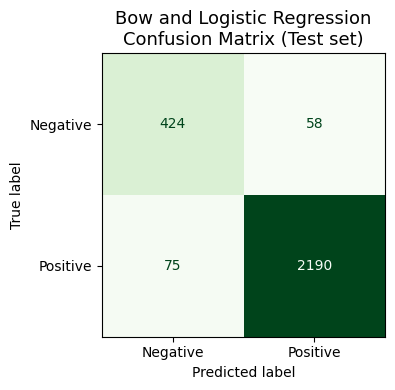

              precision    recall  f1-score   support

    Negative       0.85      0.88      0.86       482
    Positive       0.97      0.97      0.97      2265

    accuracy                           0.95      2747
   macro avg       0.91      0.92      0.92      2747
weighted avg       0.95      0.95      0.95      2747



In [27]:
fig, ax = plt.subplots(figsize=(5, 4))
###
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(test_labels, test_pred_bow)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title('Bow and Logistic Regression\nConfusion Matrix (Test set)', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=149)
plt.show()
##
print(classification_report(test_labels, test_pred_bow, target_names=['Negative', 'Positive']))


In [28]:
feature_names = vectorizer.get_feature_names_out()
weights = bow_model.coef_[0]

sorted_indices = weights.argsort()

top_neg = []
for i in sorted_indices[:10]:
    word = feature_names[i]
    top_neg.append(word)

top_pos = []
for i in reversed(sorted_indices[-10:]):
    word = feature_names[i]
    top_pos.append(word)
print("Top 10 words pushing toward POSITIVE sentiment:",top_pos )
print("Top 10 words pushing toward NEGATIVEE sentiment:", top_neg)

Top 10 words pushing toward POSITIVE sentiment: ['loved', 'perfect', 'fantastic', 'fabulous', 'pleased', 'complaint', 'spectacular', 'outstanding', 'spotless', 'london']
Top 10 words pushing toward NEGATIVEE sentiment: ['disappointing', 'poor', 'shabby', 'worst', 'poorly', 'terrible', 'cleaner', 'overpriced', 'sadly', 'dirty']


In [29]:
our_sentences = [
    'Amazing staff and the room was spotless.',
    'But others said rooms were gross and staff were rude.',
    'One loved everything, calling it perfect.',
    'Location good, service bad for some; loud and way too expensive for others.',
    "It's a mixed bag, really.",
]

print(f'  {"Sentence":<65} {"Prediction":<12} {"Confidence"}')

for sentence in our_sentences:
    cleaned = preprocess_text(sentence)

    vec     = vectorizer.transform([cleaned])
    pred    = bow_model.predict(vec)[0]
    proba   = bow_model.predict_proba(vec)[0]
    label   = 'Positive' if pred == 1.0 else 'Negative'
    conf    = proba[1] if pred == 1.0 else proba[0]

    print(f'  {sentence[:65]:<65} {label:<12} {conf:.1%}')


  Sentence                                                          Prediction   Confidence
  Amazing staff and the room was spotless.                          Positive     91.4%
  But others said rooms were gross and staff were rude.             Negative     88.9%
  One loved everything, calling it perfect.                         Positive     93.5%
  Location good, service bad for some; loud and way too expensive f Negative     83.3%
  It's a mixed bag, really.                                         Negative     71.6%


Bow can't undestand the order of the words. So "staff were never rude to us", "staff were rude never to us" would have the same meaning.

In [30]:
order_test_pair = ["staff were never rude to us", "staff were rude never to us"]
for sent in (order_test_pair):
        proc = preprocess_text(sent)
        bow_vec = vectorizer.transform([proc])
        pred = bow_model.predict(bow_vec)
        prob = bow_model.predict_proba(bow_vec).max()
        label = "Positive" if pred == 1 else "Negative"
        print(f"  '{sent}' is {label} ({prob})")


  'staff were never rude to us' is Negative (0.7803553123071271)
  'staff were rude never to us' is Negative (0.7803553123071271)



## Summary: What BoW Gets Right — and Where It Falls Short

**Strengths**
- Its simple and fast to train with no deep learning framework requirement
- 95% test accuracy on hotel sentiment is very strong
- Learned meaningful  words like horrible, disappointing and perfect, fantastic

*Limitations*
- Treats every review as a unordered bag of words counts  grammar and word order are invisible
- Cannot distinguish *'staff were **never** rude'* from *'staff were rude **never**'*
- Negations are a big problem and doesn't understand the actual meaning

BoW is a great start, often competitive. For meaning tied to word order like negations, comparisons, or conditionals, you need a sequential model, like an RNN or Transformer.